# EnergiAI — Ciencia de Datos

Hackathon ONE (Alura + Oracle) — equipo G9 LATAM

Este notebook documenta todo el trabajo de Ciencia de Datos del proyecto:

1. Exploración y limpieza de datos (EDA)
2. Análisis de patrones de consumo
3. Procesamiento y transformación de variables
4. Entrenamiento de un modelo supervisado (Random Forest)
5. Evaluación con métricas adecuadas
6. Lógica de clasificación y generación de recomendaciones
7. Serialización del modelo entrenado

El dataset (`dataset_consumo.csv`) se carga directo desde un **Pre-Authenticated Request de OCI Object Storage** (bucket `energiai-dataset`), el mismo que usa `entrenamiento.py` en producción.

## 1. Carga de datos desde OCI Object Storage

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

DATASET_URL = (
    "https://objectstorage.mx-monterrey-1.oraclecloud.com/p/"
    "vqLneS9Ystz9VrOzECrxDTSo8Iop7MS_xjdok3WbMscgsAU4QAn7pYAyI1CQInEG/"
    "n/axlcnhna5fg5/b/energiai-dataset/o/dataset_consumo.csv"
)

df = pd.read_csv(DATASET_URL)
print(f"Filas: {len(df)}, columnas: {len(df.columns)}")
df.head()

Filas: 3000, columnas: 10


,Household_Size,Avg_Temperature_C,Peak_Hours_Usage_kWh,Refrigeradores,Microondas,Lavadoras,Pantallas,Aire_Acondicionado,Focos,Energy_Consumption_kWh
0,Casa,28.8,2.04,0,1,2,4,1,7,8.12
1,Pequeño_establecimiento,32.3,3.32,0,1,2,5,3,10,17.88
2,Casa,17.0,2.86,2,1,1,4,0,8,7.55
3,Casa,27.5,1.90,4,2,2,0,0,3,7.58
4,Casa,26.0,2.94,4,2,3,5,2,20,20.15


## 2. Exploración y limpieza de datos (EDA)

Cada fila representa una vivienda o pequeño establecimiento simulado, con la cantidad de cada tipo de
electrodoméstico, la temperatura promedio de su zona, su uso en horario pico, y el consumo total
resultante (`Energy_Consumption_kWh`), calculado de abajo hacia arriba a partir de coeficientes de
consumo reales por equipo (ver `generar_dataset.py`).

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Household_Size          3000 non-null   str    
 1   Avg_Temperature_C       3000 non-null   float64
 2   Peak_Hours_Usage_kWh    3000 non-null   float64
 3   Refrigeradores          3000 non-null   int64  
 4   Microondas              3000 non-null   int64  
 5   Lavadoras               3000 non-null   int64  
 6   Pantallas               3000 non-null   int64  
 7   Aire_Acondicionado      3000 non-null   int64  
 8   Focos                   3000 non-null   int64  
 9   Energy_Consumption_kWh  3000 non-null   float64
dtypes: float64(3), int64(6), str(1)
memory usage: 234.5 KB


In [3]:
# Nulos y duplicados
print("Valores nulos por columna:")
print(df.isnull().sum())
print(f"\nFilas duplicadas: {df.duplicated().sum()}")

Valores nulos por columna:
Household_Size            0
Avg_Temperature_C         0
Peak_Hours_Usage_kWh      0
Refrigeradores            0
Microondas                0
Lavadoras                 0
Pantallas                 0
Aire_Acondicionado        0
Focos                     0
Energy_Consumption_kWh    0
dtype: int64

Filas duplicadas: 0


In [4]:
df.describe()

,Avg_Temperature_C,Peak_Hours_Usage_kWh,Refrigeradores,Microondas,Lavadoras,Pantallas,Aire_Acondicionado,Focos,Energy_Consumption_kWh
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,23.841200,2.006160,1.951667,0.988333,1.513667,2.488667,0.733667,10.994333,9.568113
std,8.047217,1.386324,1.428289,0.816753,1.111857,1.721296,1.093831,5.516803,4.561771
min,10.000000,0.030000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.300000
25%,16.900000,0.970000,1.000000,0.000000,1.000000,1.000000,0.000000,6.000000,6.237500
50%,23.700000,1.690000,2.000000,1.000000,2.000000,2.000000,0.000000,11.000000,8.525000
75%,30.700000,2.712500,3.000000,2.000000,3.000000,4.000000,1.000000,16.000000,11.930000
max,38.000000,9.000000,4.000000,2.000000,3.000000,5.000000,3.000000,20.000000,25.150000


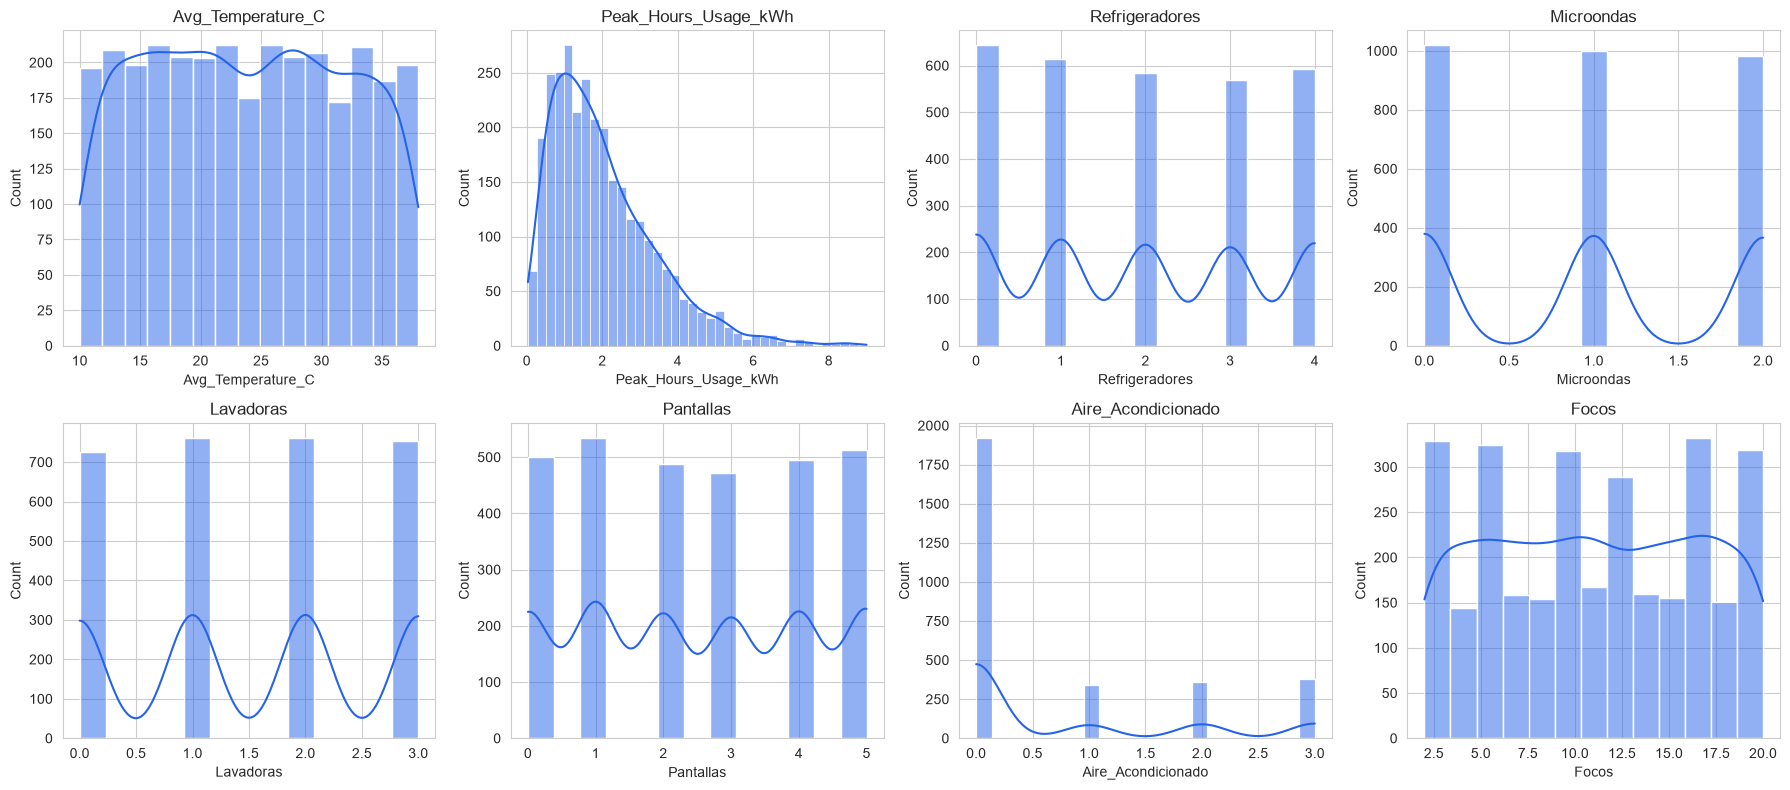

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
columnas = ["Avg_Temperature_C", "Peak_Hours_Usage_kWh", "Refrigeradores", "Microondas",
            "Lavadoras", "Pantallas", "Aire_Acondicionado", "Focos"]
for ax, col in zip(axes.flat, columnas):
    sns.histplot(df[col], kde=True, ax=ax, color="#2563eb")
    ax.set_title(col)
plt.tight_layout()
plt.savefig("eda_distribuciones.png", dpi=100)
plt.show()

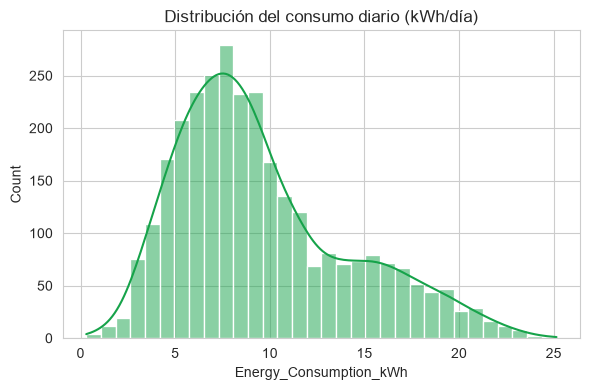

count    3000.000000
mean        9.568113
std         4.561771
min         0.300000
25%         6.237500
50%         8.525000
75%        11.930000
max        25.150000
Name: Energy_Consumption_kWh, dtype: float64


In [6]:
plt.figure(figsize=(6, 4))
sns.histplot(df["Energy_Consumption_kWh"], kde=True, color="#16a34a")
plt.title("Distribución del consumo diario (kWh/día)")
plt.xlabel("Energy_Consumption_kWh")
plt.tight_layout()
plt.savefig("eda_consumo.png", dpi=100)
plt.show()

print(df["Energy_Consumption_kWh"].describe())

## 3. Análisis de patrones de consumo

¿Qué variables se relacionan más con el consumo total? Y ¿cómo se comportan el clima y el tipo de
vivienda frente al consumo y la presencia de aire acondicionado?

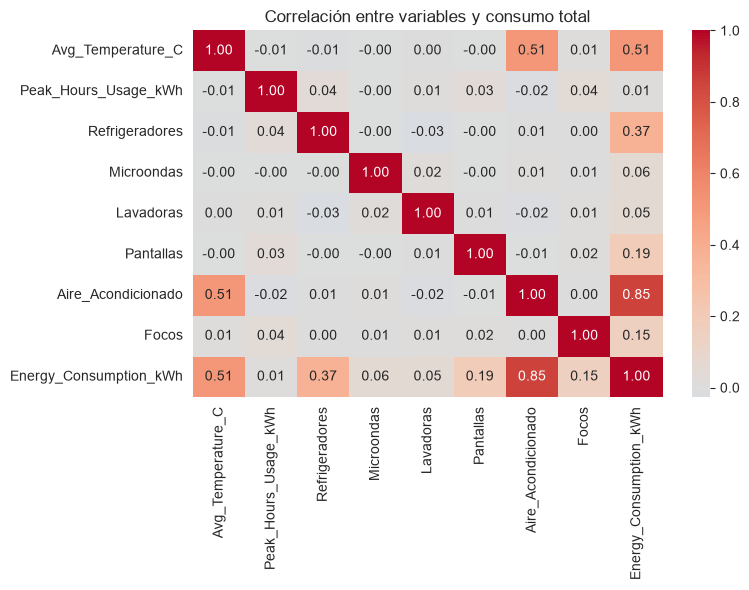

In [7]:
plt.figure(figsize=(8, 6))
correlaciones = df[columnas + ["Energy_Consumption_kWh"]].corr()
sns.heatmap(correlaciones, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlación entre variables y consumo total")
plt.tight_layout()
plt.savefig("eda_correlacion.png", dpi=100)
plt.show()

In [8]:
print("Correlación de cada variable con el consumo total, ordenada:")
print(correlaciones["Energy_Consumption_kWh"].drop("Energy_Consumption_kWh").sort_values(ascending=False))

Correlación de cada variable con el consumo total, ordenada:
Aire_Acondicionado      0.853482
Avg_Temperature_C       0.509910
Refrigeradores          0.366322
Pantallas               0.190646
Focos                   0.151866
Microondas              0.057011
Lavadoras               0.051295
Peak_Hours_Usage_kWh    0.009331
Name: Energy_Consumption_kWh, dtype: float64


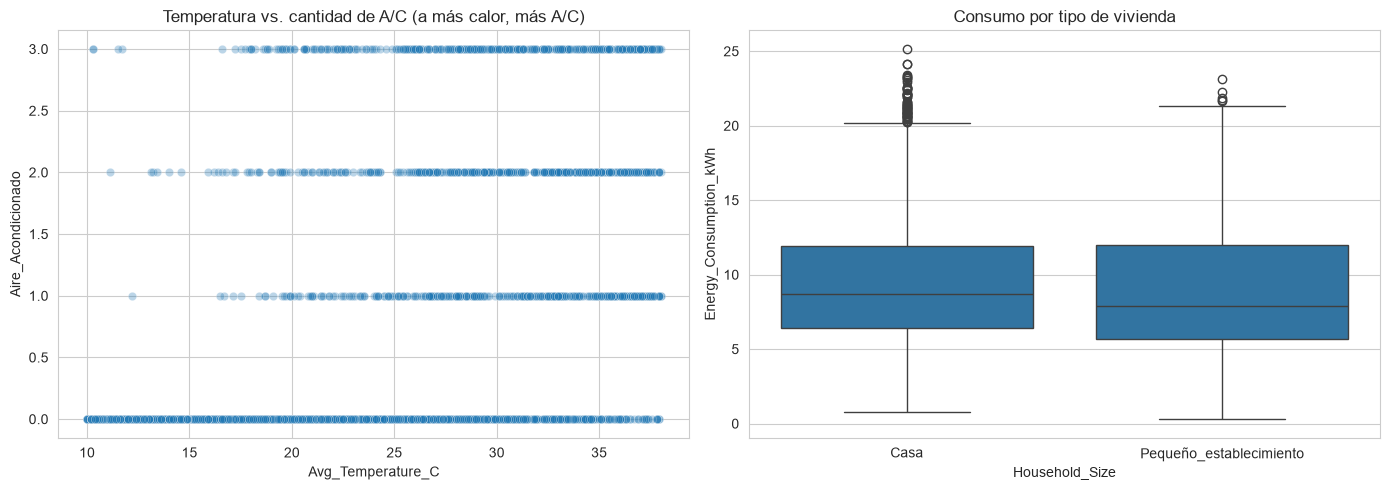

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x="Avg_Temperature_C", y="Aire_Acondicionado", alpha=0.3, ax=axes[0])
axes[0].set_title("Temperatura vs. cantidad de A/C (a más calor, más A/C)")

sns.boxplot(data=df, x="Household_Size", y="Energy_Consumption_kWh", ax=axes[1])
axes[1].set_title("Consumo por tipo de vivienda")

plt.tight_layout()
plt.savefig("eda_patrones.png", dpi=100)
plt.show()

In [10]:
# Peso relativo de cada equipo en el consumo total (coeficientes usados para generar el dataset,
# ver KWH_DIA en generar_dataset.py) — confirma que el Aire Acondicionado y los Refrigeradores son
# los que más pesan, consistente con el comportamiento real de una vivienda.
KWH_DIA = {
    "Refrigeradores": 1.20, "Microondas": 0.25, "Lavadoras": 0.30,
    "Pantallas": 0.50, "Aire_Acondicionado": 2.60, "Focos": 0.12,
}
pd.Series(KWH_DIA, name="kWh/día por unidad").sort_values(ascending=False)

Aire_Acondicionado    2.60
Refrigeradores        1.20
Pantallas             0.50
Lavadoras             0.30
Microondas            0.25
Focos                 0.12
Name: kWh/día por unidad, dtype: float64

**Hallazgos de la exploración:**

- El **Aire Acondicionado** es, por mucho, el equipo con mayor consumo individual (2.6 kWh/día por unidad), seguido de los **Refrigeradores** (1.2 kWh/día, pero presentes casi siempre).
- La probabilidad de tener aire acondicionado aumenta con la temperatura promedio de la zona — un patrón climático real, no una fuga de datos (el A/C se genera antes que el consumo total, nunca al revés).
- Ninguna variable domina por completo la correlación con el consumo total: varias (Aire Acondicionado, Refrigeradores, Pantallas, tamaño del hogar) aportan de forma repartida, lo que evita que el modelo dependa de una sola señal.

## 4. Procesamiento y transformación de variables

`Household_Size` es categórica (`Casa` / `Pequeño_establecimiento`) y se transforma con
`OneHotEncoder`. El resto de las variables (temperatura, uso en horario pico, y la cantidad de cada
electrodoméstico) ya son numéricas y pasan sin transformar.

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

columnas_categoricas = ["Household_Size"]
columnas_numericas = [
    "Avg_Temperature_C", "Peak_Hours_Usage_kWh", "Refrigeradores",
    "Microondas", "Lavadoras", "Pantallas", "Aire_Acondicionado", "Focos",
]

X = df[columnas_categoricas + columnas_numericas]
y = df["Energy_Consumption_kWh"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Entrenamiento: {len(X_train)} filas — Prueba: {len(X_test)} filas")

preprocessor = ColumnTransformer([
    ("categorical", OneHotEncoder(handle_unknown="ignore"), columnas_categoricas),
], remainder="passthrough")

Entrenamiento: 2400 filas — Prueba: 600 filas


## 5. Entrenamiento del modelo supervisado

Se usa un **`RandomForestRegressor`**: predice el consumo diario esperado (kWh/día) de una vivienda a
partir de su perfil de equipos, tamaño y clima. Se eligió regresión (en vez de clasificación directa)
porque permite comparar el consumo *real* declarado contra el *esperado* para ese mismo perfil de
equipos — de ahí sale tanto la categoría (Eficiente/Moderado/Ineficiente) como qué tan lejos está el
usuario de lo esperado, sin necesitar etiquetas de categoría previas en el dataset.

In [12]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("random_forest", RandomForestRegressor(
        n_estimators=200, max_depth=10, min_samples_leaf=5, random_state=42
    )),
])

pipeline.fit(X_train, y_train)
print("Modelo entrenado.")

Modelo entrenado.


## 6. Evaluación con métricas adecuadas

In [13]:
y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.4f} kWh/día")
print(f"RMSE: {rmse:.4f} kWh/día")
print(f"R²  : {r2:.4f}")

MAE : 0.8392 kWh/día
RMSE: 1.0579 kWh/día
R²  : 0.9462


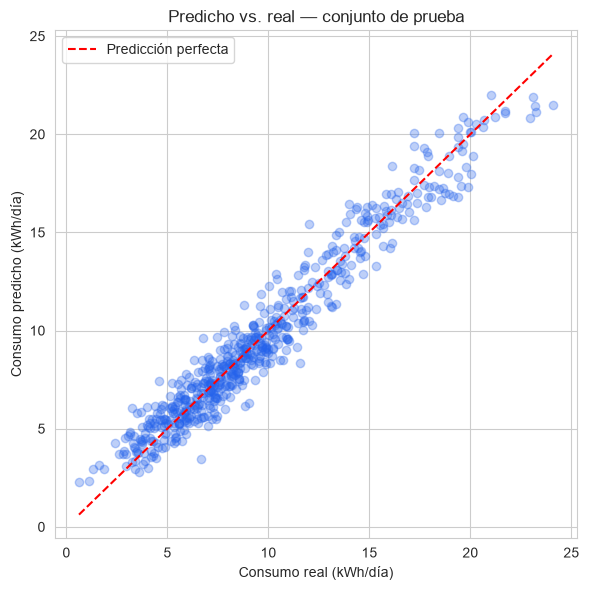

In [14]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color="#2563eb")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "r--", label="Predicción perfecta")
plt.xlabel("Consumo real (kWh/día)")
plt.ylabel("Consumo predicho (kWh/día)")
plt.title("Predicho vs. real — conjunto de prueba")
plt.legend()
plt.tight_layout()
plt.savefig("eda_prediccion.png", dpi=100)
plt.show()

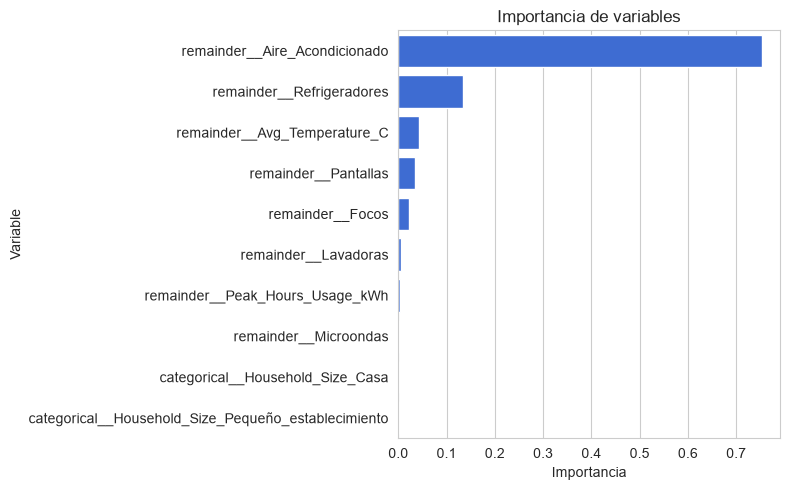

,Variable,Importancia
0,remainder__Aire_Acondicionado,0.753030
1,remainder__Refrigeradores,0.134137
2,remainder__Avg_Temperature_C,0.042593
3,remainder__Pantallas,0.034689
4,remainder__Focos,0.022191
5,remainder__Lavadoras,0.004700
6,remainder__Peak_Hours_Usage_kWh,0.003852
7,remainder__Microondas,0.001881
8,categorical__Household_Size_Casa,0.001538
9,categorical__Household_Size_Pequeño_establecim...,0.001390


In [15]:
rf = pipeline.named_steps["random_forest"]
nombres_variables = pipeline.named_steps["preprocessor"].get_feature_names_out()

importancia_df = pd.DataFrame({
    "Variable": nombres_variables,
    "Importancia": rf.feature_importances_,
}).sort_values("Importancia", ascending=False).reset_index(drop=True)

plt.figure(figsize=(8, 5))
sns.barplot(data=importancia_df, x="Importancia", y="Variable", color="#2563eb")
plt.title("Importancia de variables")
plt.tight_layout()
plt.savefig("eda_importancia.png", dpi=100)
plt.show()

importancia_df

Ninguna variable domina por completo la importancia (a diferencia de una versión anterior del
dataset, donde `Peak_Hours_Usage_kWh` concentraba ~97% de la importancia por una fuga de datos:
las cantidades de equipos se generaban a partir del consumo real, en vez de al revés). Aquí el
consumo se calculó desde los equipos hacia el consumo total, así que el Aire Acondicionado y los
Refrigeradores —los que más kWh consumen por unidad— son los que más pesan, de forma realista.

## 7. Clasificación y generación de recomendaciones

El backend (`AnalisisService.java`) usa el consumo *predicho* por este modelo como referencia y compara
contra el consumo *real* declarado por el usuario:

| Diferencia (real vs. esperado) | Categoría |
|---|---|
| Real muy por debajo de lo esperado (más de 15% menos) | **Eficiente** |
| Real dentro de ±15% de lo esperado | **Moderado** |
| Real muy por encima de lo esperado (más de 15% de más) | **Ineficiente** |

La probabilidad reportada es `max(0, min(1, 1 - |diferencia porcentual| / 100))` — entre más cerca esté
el consumo real del esperado, mayor la confianza de la clasificación.

Las **recomendaciones son basadas en reglas** (no en el modelo directamente): a partir del consumo
estimado por tipo de equipo (cantidad × coeficiente kWh/día × tarifa de referencia $0.75/kWh), el
backend identifica los equipos que más pesan en el consumo total y arma un mensaje específico por cada
uno (p. ej. subir 1-2°C al aire acondicionado, revisar empaques del refrigerador, cambiar focos a LED),
más una recomendación sobre el uso en horario pico si supera cierto umbral del consumo total.

In [16]:
def clasificar(consumo_real_mensual, consumo_esperado_diario, margen=0.15):
    """Réplica en Python de la regla de clasificación que usa el backend (Java),
    solo para ilustrar la lógica dentro del notebook."""
    real_diario = consumo_real_mensual / 30
    diferencia_pct = (real_diario - consumo_esperado_diario) / consumo_esperado_diario

    if diferencia_pct < -margen:
        categoria = "Eficiente"
    elif diferencia_pct > margen:
        categoria = "Ineficiente"
    else:
        categoria = "Moderado"

    probabilidad = max(0.0, min(1.0, 1 - abs(diferencia_pct)))
    return categoria, round(probabilidad, 4)

# Ejemplo: una vivienda con consumo esperado de 6.83 kWh/día según el modelo
print(clasificar(260, 6.83))   # dentro del margen -> Moderado
print(clasificar(150, 6.83))   # muy por debajo -> Eficiente
print(clasificar(400, 6.83))   # muy por encima -> Ineficiente

('Ineficiente', 0.7311)
('Eficiente', 0.7321)
('Ineficiente', 0.0478)


## 8. Serialización del modelo entrenado

In [17]:
import joblib

joblib.dump({
    "modelo": pipeline,
    "variables": list(X.columns),
}, "random_forest_consumo_notebook.pkl")

print("Modelo guardado en random_forest_consumo_notebook.pkl")
print("(El modelo servido en producción, random_forest_consumo.pkl, se genera igual con entrenamiento.py)")

Modelo guardado en random_forest_consumo_notebook.pkl
(El modelo servido en producción, random_forest_consumo.pkl, se genera igual con entrenamiento.py)


## 9. Ejemplos de uso reales (API en producción)

Estos tres casos se probaron directamente contra la API desplegada en Railway
(`POST /analisis-energetico`), uno por cada categoría posible.

In [18]:
ejemplos = [
    {
        "nombre": "Caso Eficiente",
        "entrada": {"consumo_kwh": 260, "uso_horario_pico_kwh": 40, "tamano_hogar": 4,
                    "temperatura_promedio": 30, "refrigeradores": 2, "microondas": 1,
                    "lavadoras": 2, "pantallas": 3, "aire_acondicionado": 2, "focos": 15,
                    "mes": "Junio", "anio": 2026},
        "salida": {"categoria": "Eficiente", "probabilidad": 0.5741,
                   "costo_estimado_mensual": 195.0, "consumo_kwh": 260.0},
    },
    {
        "nombre": "Caso Moderado",
        "entrada": {"consumo_kwh": 420, "uso_horario_pico_kwh": 150, "tamano_hogar": 4,
                    "temperatura_promedio": 30, "refrigeradores": 2, "microondas": 1,
                    "lavadoras": 2, "pantallas": 3, "aire_acondicionado": 2, "focos": 15,
                    "mes": "Julio", "anio": 2026},
        "salida": {"categoria": "Moderado", "probabilidad": 0.9309,
                   "costo_estimado_mensual": 315.0, "consumo_kwh": 420.0},
    },
    {
        "nombre": "Caso Ineficiente",
        "entrada": {"consumo_kwh": 180, "uso_horario_pico_kwh": 20, "tamano_hogar": 2,
                    "temperatura_promedio": 22, "refrigeradores": 1, "microondas": 1,
                    "lavadoras": 1, "pantallas": 1, "aire_acondicionado": 0, "focos": 6,
                    "mes": "Marzo", "anio": 2026},
        "salida": {"categoria": "Ineficiente", "probabilidad": 0.5481,
                   "costo_estimado_mensual": 135.0, "consumo_kwh": 180.0},
    },
]

for ejemplo in ejemplos:
    print(f"--- {ejemplo['nombre']} ---")
    print("Entrada:", ejemplo["entrada"])
    print("Salida :", ejemplo["salida"])
    print()

--- Caso Eficiente ---
Entrada: {'consumo_kwh': 260, 'uso_horario_pico_kwh': 40, 'tamano_hogar': 4, 'temperatura_promedio': 30, 'refrigeradores': 2, 'microondas': 1, 'lavadoras': 2, 'pantallas': 3, 'aire_acondicionado': 2, 'focos': 15, 'mes': 'Junio', 'anio': 2026}
Salida : {'categoria': 'Eficiente', 'probabilidad': 0.5741, 'costo_estimado_mensual': 195.0, 'consumo_kwh': 260.0}

--- Caso Moderado ---
Entrada: {'consumo_kwh': 420, 'uso_horario_pico_kwh': 150, 'tamano_hogar': 4, 'temperatura_promedio': 30, 'refrigeradores': 2, 'microondas': 1, 'lavadoras': 2, 'pantallas': 3, 'aire_acondicionado': 2, 'focos': 15, 'mes': 'Julio', 'anio': 2026}
Salida : {'categoria': 'Moderado', 'probabilidad': 0.9309, 'costo_estimado_mensual': 315.0, 'consumo_kwh': 420.0}

--- Caso Ineficiente ---
Entrada: {'consumo_kwh': 180, 'uso_horario_pico_kwh': 20, 'tamano_hogar': 2, 'temperatura_promedio': 22, 'refrigeradores': 1, 'microondas': 1, 'lavadoras': 1, 'pantallas': 1, 'aire_acondicionado': 0, 'focos': 6, 

---

**Resumen:** este notebook cubre exploración y limpieza de datos, análisis de patrones de consumo,
transformación de variables, entrenamiento de un `RandomForestRegressor`, evaluación con MAE/RMSE/R²,
la lógica de clasificación y recomendaciones basadas en reglas, y la serialización del modelo — el
mismo flujo que corre en producción vía `entrenamiento.py` y se sirve con `servidor.py` (FastAPI) como
un servicio independiente en Railway.